In [2]:
import pandas as pd
import numpy as np
from scipy.spatial import Voronoi
from matplotlib import pyplot as plt

### 1. Generation of the particles coordinates on a square grid

In [3]:
# initialising parameters of the bidisperse mixture

# number of particles
nb_big_side = 20
nb_small_side = nb_big_side - 1
nb_big = nb_big_side**2
nb_small = nb_small_side**2

coord = np.zeros([nb_big+nb_small, 7])

# Physical size dimensions
dist_param = 1. # distance parameter to link with physical forces constants

side_size = 1. * dist_param
density_big = 1./(side_size**2)
density_small = 1./(side_size**2)
side_sample = nb_big_side * side_size
surface_sample = side_sample**2

# noise in positions of particles generation
noise_param = 0.05



In [4]:
# Generating coordinates array
idx = 0
np.random.seed(0)

def noise_gen(noise_param = noise_param): # generating quasi normal random noise with max abs noise set to side_size/10.
    noise = 0.
    if noise_param * side_size * np.random.randn() >= 0. :
        noise = np.min([noise_param * side_size * np.random.randn(), side_size/10.])
    else:
        noise = np.max(([noise_param * side_size * np.random.randn(), -side_size/10.]))

    return noise

# for big particles
for j in range(nb_big_side): # columns generation
    
    for i in range(nb_big_side): # rows generation
        pos_x = side_size/2. + i * side_size + noise_gen()
        pos_y = side_size/2. + j * side_size + noise_gen()

        coord[idx, 0] = idx
        coord[idx, 1] = pos_x
        coord[idx, 2] = pos_y
        coord[idx, 3] = 1

        if (j == 0 or j == nb_big_side-1 or i == 0 or i == nb_big_side-1):
            coord[idx, 6] = 1.
        else:
            coord[idx, 6] = 0.

        idx += 1

# for small particles
for j in range(nb_small_side): # columns generation

    for i in range(nb_small_side): # rows generation
        pos_x = side_size + i * side_size + noise_gen()
        pos_y = side_size + j * side_size + noise_gen()

        coord[idx, 0] = idx
        coord[idx, 1] = pos_x
        coord[idx, 2] = pos_y
        coord[idx, 3] = 0

        if (j == 0 or j == nb_small_side-1 or i == 0 or i == nb_small_side-1):
            coord[idx, 6] = 1.
        else:
            coord[idx, 6] = 0.

        idx += 1


coord[:10]

array([[0.        , 0.52000786, 0.6       , 1.        , 0.        ,
        0.        , 1.        ],
       [1.        , 1.45113611, 0.49243214, 1.        , 0.        ,
        0.        , 1.        ],
       [2.        , 2.52052993, 0.57271368, 1.        , 0.        ,
        0.        , 1.        ],
       [3.        , 3.50608375, 0.51668372, 1.        , 0.        ,
        0.        , 1.        ],
       [4.        , 4.48974209, 0.45729521, 1.        , 0.        ,
        0.        , 1.        ],
       [5.        , 5.53268093, 0.46289175, 1.        , 0.        ,
        0.        , 1.        ],
       [6.        , 6.42728172, 0.49064081, 1.        , 0.        ,
        0.        , 1.        ],
       [7.        , 7.57346794, 0.51890813, 1.        , 0.        ,
        0.        , 1.        ],
       [8.        , 8.40096018, 0.50781745, 1.        , 0.        ,
        0.        , 1.        ],
       [9.        , 9.56011899, 0.48488486, 1.        , 0.        ,
        0.        , 1. 

In [5]:
coord[-10:]

array([[751.        ,   9.98031331,  19.0049711 ,   0.        ,
          0.        ,   0.        ,   1.        ],
       [752.        ,  11.01638116,  18.98114744,   0.        ,
          0.        ,   0.        ,   1.        ],
       [753.        ,  11.92582542,  19.00673436,   0.        ,
          0.        ,   0.        ,   1.        ],
       [754.        ,  12.99942222,  18.9913035 ,   0.        ,
          0.        ,   0.        ,   1.        ],
       [755.        ,  13.99246732,  18.98826528,   0.        ,
          0.        ,   0.        ,   1.        ],
       [756.        ,  14.92107349,  19.0785152 ,   0.        ,
          0.        ,   0.        ,   1.        ],
       [757.        ,  16.02361639,  19.01051157,   0.        ,
          0.        ,   0.        ,   1.        ],
       [758.        ,  16.96452395,  19.02960745,   0.        ,
          0.        ,   0.        ,   1.        ],
       [759.        ,  17.94117634,  19.08308259,   0.        ,
          0.    

In [6]:
# voronoi tesselation with scipy
vr = Voronoi(coord[:, [1,2]])

In [7]:
vr.vertices.shape

(1505, 2)

In [8]:
vr.vertices[:10,0]

array([   0.47447658,    6.0958413 ,   11.60502108,  -18.14111182,
        152.02162803,  -22.78664649,    0.95099057,   -5.98020044,
          0.51757013, -253.1802098 ])

(0.0, 10.0)

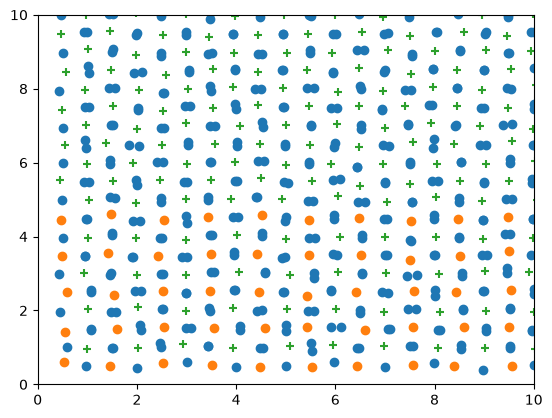

In [9]:
plt.scatter(x=vr.vertices[:, 0], y=vr.vertices[:,1])
plt.scatter(x=coord[:100, 1], y=coord[:100, 2])
plt.scatter(x=coord[100:, 1], y=coord[100:, 2], marker="+")
plt.xlim(0,10)
plt.ylim(0,10)

(array([[  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   2.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   2.,
           4.,   1.,   0., 116., 155., 157., 157., 156., 159., 158., 151.,
         157., 108.,   0.,   0.,   1.,   1.,   1.,   1.,   1.,   0.,   0.,
           0.,   1.,   1.,   0.,   0.,   1.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,
           0.,   2.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   2.,
           1.,   0.,   1., 109., 162., 152., 151., 169., 144., 162., 161.,
         152., 112.,   0.,   1.,   1.,   3.,   0.,   0.,   2.,   0.,   0.,
           0.,   1.,   0.,   1.,   0.,   0.]]),
 array([-50., -48., -46., -44., -42., -40., -38., -36., -34., -32., -30.,
        -28., -26., -24., -22., -20., -18., -16., -14., -12., -10.,  -8.,
         -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,
         16.,  18.,  20.,  22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,
         3

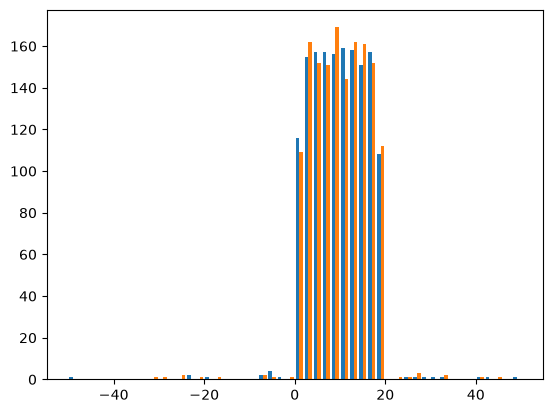

In [10]:
plt.hist(vr.vertices, range= [-50,50], bins=50)

In [11]:
# We won't use voronoy diagram to compute potential energy and force 
# but select the closest neighbors being given a typical distance in which these neighbors fall

In [12]:
neigh_dist = 1. * side_size

def neigh_xy(pos_x = nb_big_side * side_size/2., pos_y = nb_big_side * side_size/2.,coord = coord,
             neigh_dist = neigh_dist):
    neigh = np.where(np.sqrt(np.square(coord[:,1]-pos_x)+np.square(coord[:,2]-pos_y)) < neigh_dist)
    return neigh

In [13]:
neigh_xy()

(array([189, 190, 209, 210, 561, 580, 599]),)

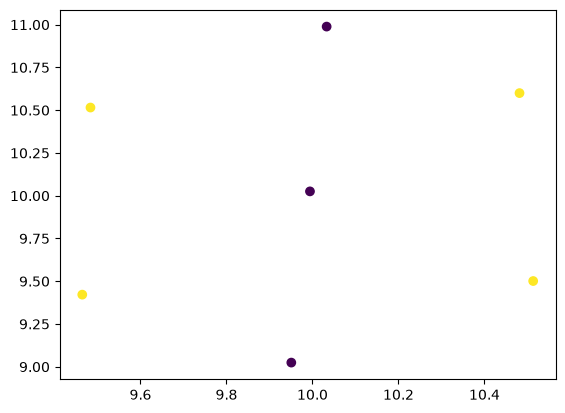

In [14]:
c_map = {1: 'b', 0: 'r'}


plt.scatter(x=coord[neigh_xy(), 1], y=coord[neigh_xy(), 2], c=coord[neigh_xy(), 3])

In [15]:
neigh_dist = 1. * side_size

# Physical force parameters
big_f = 0.1
small_f = 0.05
mass_big = 1
mass_small = 0.5

# testing coordinates
pos_x = nb_big_side * side_size/2.
pos_y = nb_big_side * side_size/2.

def force_xy(pos_x = nb_big_side * side_size/2., pos_y = nb_big_side * side_size/2.,coord = coord,
             neigh_dist = neigh_dist, big_f = big_f, small_f = small_f):
    """ this function determines the force exerted  at a given position by closest neighbors"""

    neigh = np.where(np.sqrt(np.square(coord[:,1]-pos_x)+np.square(coord[:,2]-pos_y)) < neigh_dist)
    
    f_xy = np.zeros([len(neigh[0]), 2])
    
    for partic in range(len(neigh[0])):    
        if coord[neigh[0][partic],3] == 1:
            f_xy[partic] = [big_f * (pos_x - coord[neigh[0][partic],1]), big_f * (pos_y - coord[neigh[0][partic],2])]/(np.square(coord[neigh[0][partic],1]-pos_x)+np.square(coord[neigh[0][partic],2]-pos_y))
        else:
            f_xy[partic] = [small_f * (pos_x - coord[neigh[0][partic],1]), small_f * (pos_y - coord[neigh[0][partic],2])]/(np.square(coord[neigh[0][partic],1]-pos_x)+np.square(coord[neigh[0][partic],2]-pos_y))   

    force_xy = np.sum(f_xy, axis = 0)

    return force_xy

force_xy()

array([ 0.42999285, -1.87672732])

In [16]:
# not to forget, in case we want to calculate the force exerted on a particle, not taking in account the force of the particle on itself
# partic_index 
# for partic in range(len(neigh[0])): 
#    if coord[neigh[0][partic],0] != partic_index:
# ....
def force_partic(idx_partic = 0, coord = coord,
             neigh_dist = neigh_dist, big_f = big_f, small_f = small_f):
    """ this function determines the force exerted  of a given particle by closest neighbors"""
    pos_x = coord[idx_partic, 1]
    pos_y = coord[idx_partic, 2]

    neigh = np.where(np.sqrt(np.square(coord[:,1]-pos_x)+np.square(coord[:,2]-pos_y)) < neigh_dist)
    
    f_xy = np.zeros([len(neigh[0]), 2])
    
    for partic in range(len(neigh[0])):
        if coord[neigh[0][partic],0] != idx_partic:   
            if coord[neigh[0][partic],3] == 1:
                f_xy[partic] = [big_f * (pos_x - coord[neigh[0][partic],1]), big_f * (pos_y - coord[neigh[0][partic],2])]/(np.square(coord[neigh[0][partic],1]-pos_x)+np.square(coord[neigh[0][partic],2]-pos_y))
            else:
                f_xy[partic] = [small_f * (pos_x - coord[neigh[0][partic],1]), small_f * (pos_y - coord[neigh[0][partic],2])]/(np.square(coord[neigh[0][partic],1]-pos_x)+np.square(coord[neigh[0][partic],2]-pos_y))   

    force_xy = np.sum(f_xy, axis = 0)

    return force_xy

force_partic()

array([-0.17677399, -0.16009504])

In [17]:
# computation of a step of deplacement for a given particle
time_step = 0.1
display(coord[0,:])
def partic_move(idx_partic=0, coord=coord, time_step=time_step):
    speed = [coord[idx_partic, 4], coord[idx_partic, 5]]
    f_xy = force_partic(idx_partic, coord, neigh_dist, big_f, small_f)
    
    if coord[idx_partic, 3] == 1.:
        m_partic = mass_big
    else:
        m_partic = mass_small
    speed += f_xy * time_step / m_partic

    coord_1 = coord.copy()
    coord_1[idx_partic, 4:6] = speed 
    coord_1[idx_partic, 1:3] += speed * time_step

    return coord_1

coord_1 = partic_move()
coord_1[0,:]

array([0.        , 0.52000786, 0.6       , 1.        , 0.        ,
       0.        , 1.        ])

array([ 0.        ,  0.51824012,  0.59839905,  1.        , -0.0176774 ,
       -0.0160095 ,  1.        ])

In [18]:
# test for the dynamics of the 0th particle, should obtain a line slowing
n_step = 10

coord_0 = coord.copy()
coord_time = np.zeros([n_step, 2])
for step_i in range (n_step):
    coord_0 = partic_move(coord=coord_0)
    coord_time[step_i, :] = coord_0[0, 1:3]

coord_time

array([[0.51824012, 0.59839905],
       [0.51470659, 0.59519924],
       [0.50941116, 0.59040475],
       [0.50235967, 0.58402186],
       [0.49355988, 0.57605893],
       [0.4830215 , 0.5665264 ],
       [0.47075613, 0.55543681],
       [0.45677732, 0.54280473],
       [0.44110056, 0.52864676],
       [0.42473205, 0.51294599]])

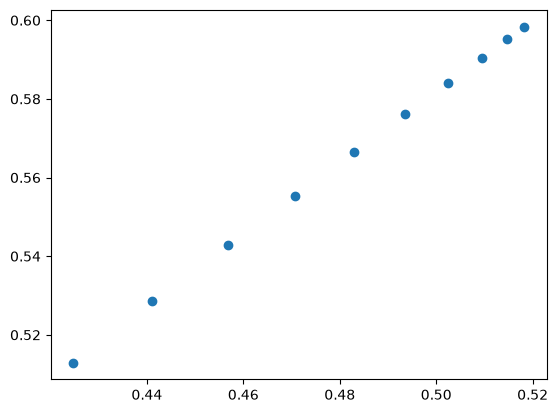

In [19]:
plt.scatter(x=coord_time[:,0], y=coord_time[:,1])

In [20]:
# test for the dynamics of a particle in the core of the sample
n_step = 10
idx_partic = 25

coord_0 = coord.copy()
coord_time = np.zeros([n_step, 2])
for step_i in range (n_step):
    coord_1 = partic_move(idx_partic=idx_partic, coord=coord_1)
    coord_time[step_i, :] = coord_1[idx_partic, 1:3]

coord_time

array([[5.43371235, 1.54745128],
       [5.43591329, 1.54541475],
       [5.4392155 , 1.54236135],
       [5.44361989, 1.53829277],
       [5.4491276 , 1.53321122],
       [5.45573988, 1.52711945],
       [5.46345797, 1.52002073],
       [5.47228299, 1.51191887],
       [5.48221568, 1.50281826],
       [5.4932562 , 1.49272391]])

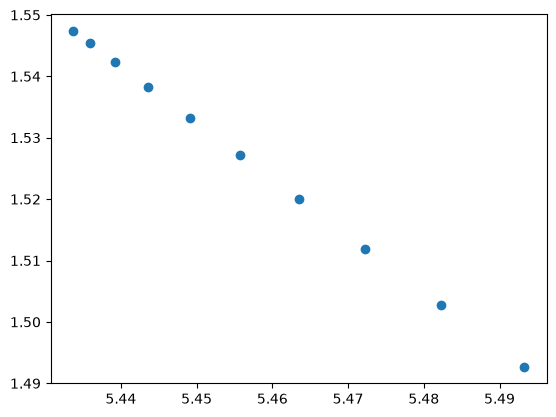

In [21]:
plt.scatter(x=coord_time[:,0], y=coord_time[:,1])

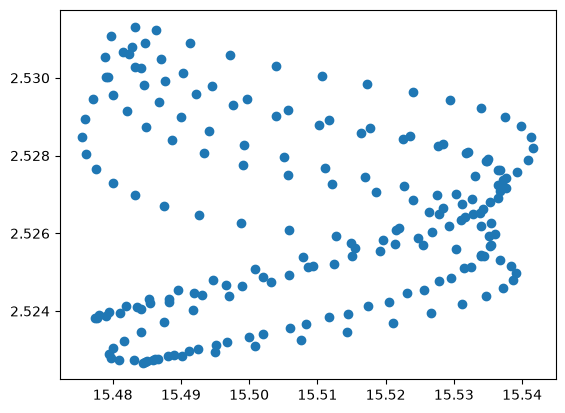

In [22]:

idx_partic = 55
n_step = 200
coord_0 = coord.copy()

def single_partic_traj(idx_partic = idx_partic, n_step = n_step, coord = coord):
    coord_1 = coord.copy()
    coord_time = np.zeros([n_step, 2])
    for step_i in range (n_step):
        coord_1 = partic_move(idx_partic=idx_partic, coord=coord_1)
        coord_time[step_i, :] = coord_1[idx_partic, 1:3]

    return coord_time

coord_time=single_partic_traj(coord = coord_0)
plt.scatter(x=coord_time[:,0], y=coord_time[:,1])

In [23]:
coord_1 = coord.copy()
coord_1.shape

(761, 7)

In [24]:
n_step = 1
time_step = 0.5
coord_0 = coord.copy()
coord_1 = coord.copy()

def all_partic_1step(coord = coord_1):
    coord_2 = coord.copy() 
    
    for idx_partic in range(nb_big + nb_small):
        if coord_2[idx_partic,6] == 0:
            coord_2[idx_partic,:] = partic_move(idx_partic=idx_partic, coord=coord, time_step=time_step)[idx_partic,:]
            
        else:
            coord_2[idx_partic,:] = coord_2[idx_partic,:]
            
    return coord_2

coord_2 = all_partic_1step()


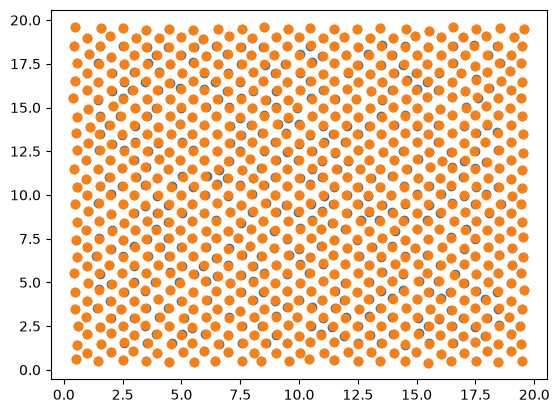

In [25]:
plt.scatter(x=coord_1[:,1], y=coord_1[:,2])
plt.scatter(x=coord_2[:,1], y=coord_2[:,2])

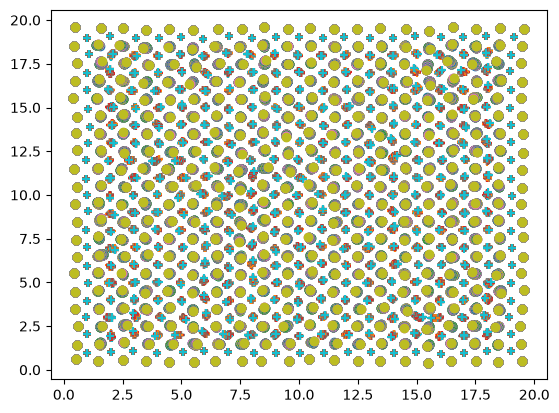

In [26]:
n_step = 100
time_step = 0.05
coord_1 = coord.copy()

def marker_partic(x):

    return "o" if x == 1 else "+"

for step in range(n_step): 
    coord_1 = coord_2.copy()
    coord_2 = all_partic_1step(coord = coord_1)
    
    plt.scatter(x=coord_1[np.where(coord_1[:,3]==1),1], y=coord_1[np.where(coord_1[:,3]==1),2], marker="o")
    plt.scatter(x=coord_1[np.where(coord_1[:,3]==0),1], y=coord_1[np.where(coord_1[:,3]==0),2], marker="+")
    

In [27]:
coord_1.shape

(761, 7)

### 3. Functions for a whole simulation process

In [47]:
# initialising parameters of the bidisperse mixture

# number of particles
nb_big_side = 20
nb_small_side = nb_big_side - 1
nb_big = nb_big_side**2
nb_small = nb_small_side**2

coord = np.zeros([nb_big+nb_small, 7])

# Physical size dimensions
dist_param = 1. # distance parameter to link with physical forces constants

side_size = 1. * dist_param
density_big = 1./(side_size**2)
density_small = 1./(side_size**2)
side_sample = nb_big_side * side_size
surface_sample = side_sample**2

# noise in positions of particles generation
noise_param = 0.05

In [48]:
np.random.seed(0)

def noise_gen(noise_param = noise_param): # generating quasi normal random noise with max abs noise set to side_size/10.
    noise = 0.
    if noise_param * side_size * np.random.randn() >= 0. :
        noise = np.min([noise_param * side_size * np.random.randn(), side_size/10.])
    else:
        noise = np.max(([noise_param * side_size * np.random.randn(), -side_size/10.]))

    return noise


def generate_square_grid(density_big = density_big, sample_x_size = side_size * 10, sample_y_size = side_size * 10, noise_param = noise_param):
    
    surface_sample = sample_x_size * sample_y_size
    nb_big = surface_sample * density_big
    nb_small = surface_sample * density_small

    side_size = 1./np.sqrt(density_big)
    nb_big_x = int(np.sqrt(density_big)*sample_x_size)
    nb_big_y = int(np.sqrt(density_big)*sample_y_size)
    
    #nb_small_x = int(np.sqrt(density_small)*sample_x_size)
    #nb_small_y = int(np.sqrt(density_small)*sample_y_size) 

    nb_small_x = nb_big_x -1
    nb_small_y = nb_big_y -1

    coord = np.zeros([(nb_big_x*nb_big_y) + (nb_small_x*nb_small_y), 7])

    idx = 0
    
    # for big particles
    for j in range(nb_big_y): # columns generation
        
        for i in range(nb_big_x): # rows generation
            pos_x = side_size/2. + i * side_size + noise_gen(noise_param=noise_param)
            pos_y = side_size/2. + j * side_size + noise_gen(noise_param=noise_param)

            coord[idx, 0] = idx
            coord[idx, 1] = pos_x
            coord[idx, 2] = pos_y
            coord[idx, 3] = 1

# to do fixing a boarder of non moving particles of at least 1 side_size

            dist_boarder_x0 = np.sqrt(pos_x**2)
            dist_boarder_x1 = np.sqrt((sample_x_size-pos_x)**2)
            dist_boarder_y0 = np.sqrt(pos_y**2)
            dist_boarder_y1 = np.sqrt((sample_y_size-pos_y)**2)

            if (dist_boarder_x0 <= side_size or dist_boarder_x1 <= side_size or dist_boarder_y0 <= side_size or dist_boarder_y1 <= side_size):
                coord[idx, 6] = 1.
            else:
                coord[idx, 6] = 0.

            idx += 1

    # for small particles
    for j in range(nb_small_y): # columns generation

        for i in range(nb_small_x): # rows generation
            pos_x = side_size + i * side_size + noise_gen(noise_param=noise_param)
            pos_y = side_size + j * side_size + noise_gen(noise_param=noise_param)

            coord[idx, 0] = idx
            coord[idx, 1] = pos_x
            coord[idx, 2] = pos_y
            coord[idx, 3] = 0

            dist_boarder_x0 = np.sqrt(pos_x**2)
            dist_boarder_x1 = np.sqrt((sample_x_size-pos_x)**2)
            dist_boarder_y0 = np.sqrt(pos_y**2)
            dist_boarder_y1 = np.sqrt((sample_y_size-pos_y)**2)

            if (dist_boarder_x0 <= side_size or dist_boarder_x1 <= side_size or dist_boarder_y0 <= side_size or dist_boarder_y1 <= side_size):
                coord[idx, 6] = 1.
            else:
                coord[idx, 6] = 0.

            idx += 1
    return coord

In [49]:
coord0 = generate_square_grid()
coord0.shape

(181, 7)

(0.0, 10.0)

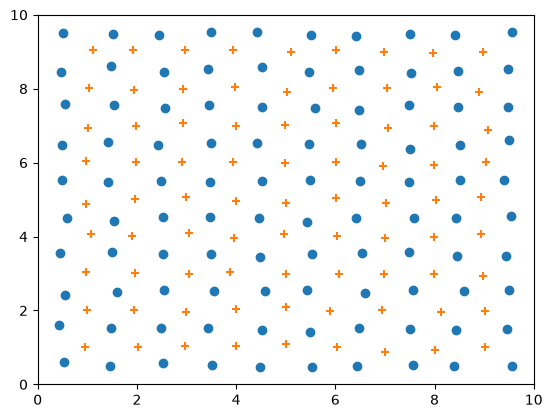

In [50]:
plt.scatter(x=coord0[:100, 1], y=coord0[:100, 2])
plt.scatter(x=coord0[100:, 1], y=coord0[100:, 2], marker="+")
plt.xlim(0,10)
plt.ylim(0,10)